In [1]:
import os
from PIL import Image

# **I. Import data**

In [6]:
# Giải nén tệp
!unzip -o -q "/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/raw/archive.zip" -d /content/data

# Thiết lập đường dẫn thư mục dựa trên cấu trúc thực tế
data_dir = '/content/data/Dataset'

print("Giải nén và cập nhật đường dẫn hoàn tất.")

Giải nén và cập nhật đường dẫn hoàn tất.


# **II. Khai phá dữ liệu - EDA (Exploratory Data Analysis)**

In [3]:
import os
from PIL import Image

# Install Pillow if not already installed (useful for fresh Colab runtimes)
try:
    import PIL
except ImportError:
    %pip install Pillow
    from PIL import Image

## **II.1. Kiểm tra tính toàn vẹn của dữ liệu (Dataset Integrity)**

- Thống kê số lượng: Đếm số lượng ảnh trong mỗi thư mục (mỗi lớp).

- Mục tiêu: Phát hiện tình trạng Data Imbalance. Điều này sẽ khiến mô hình bị thiên kiến.

- Kiểm tra định dạng: Đảm bảo tất cả là .jpg, .png... và không có file rác hoặc file bị lỗi (corrupted).

In [7]:
print(f"Kiểm tra thư mục dữ liệu: {data_dir}\n")

class_counts = {}
invalid_files = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff') # Common image extensions

# Lặp qua các thư mục con (lớp) trong thư mục dataset
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    # Đảm bảo đây là một thư mục
    if os.path.isdir(class_path):
        print(f"Đang kiểm tra lớp: {class_name}")
        count = 0

        # Lặp qua các tệp trong thư mục lớp
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)

            if os.path.isfile(file_path):
                # Kiểm tra định dạng tệp cơ bản
                if not filename.lower().endswith(valid_extensions):
                    invalid_files.append((file_path, 'Invalid Extension'))
                    continue

                # Cố gắng mở tệp để kiểm tra xem nó có phải là hình ảnh hợp lệ không
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Xác minh rằng đây thực sự là một tệp hình ảnh
                        count += 1
                except Exception as e:
                    invalid_files.append((file_path, str(e)))
        class_counts[class_name] = count

print("\n--- Kết quả thống kê số lượng ảnh trên mỗi lớp ---")
for class_name, count in class_counts.items():
    print(f"Lớp '{class_name}': {count} ảnh")

print("\n--- Kiểm tra định dạng và tệp bị lỗi ---")
if invalid_files:
    print("Phát hiện các tệp không hợp lệ hoặc bị lỗi:")
    for file, error in invalid_files:
        print(f"- Tệp: {file}, Lỗi: {error}")
else:
    print("Không tìm thấy tệp không hợp lệ hoặc bị lỗi nào.")

print("\nHoàn tất kiểm tra tính toàn vẹn dữ liệu.")

Kiểm tra thư mục dữ liệu: /content/data/Dataset

Đang kiểm tra lớp: P
Đang kiểm tra lớp: Y
Đang kiểm tra lớp: D
Đang kiểm tra lớp: AA
Đang kiểm tra lớp: DD
Đang kiểm tra lớp: H
Đang kiểm tra lớp: K
Đang kiểm tra lớp: R
Đang kiểm tra lớp: V
Đang kiểm tra lớp: X
Đang kiểm tra lớp: OOO
Đang kiểm tra lớp: U
Đang kiểm tra lớp: C
Đang kiểm tra lớp: B
Đang kiểm tra lớp: A
Đang kiểm tra lớp: T
Đang kiểm tra lớp: G
Đang kiểm tra lớp: L
Đang kiểm tra lớp: AAA
Đang kiểm tra lớp: E
Đang kiểm tra lớp: S
Đang kiểm tra lớp: N
Đang kiểm tra lớp: I
Đang kiểm tra lớp: Q
Đang kiểm tra lớp: O
Đang kiểm tra lớp: M

--- Kết quả thống kê số lượng ảnh trên mỗi lớp ---
Lớp 'P': 1000 ảnh
Lớp 'Y': 1000 ảnh
Lớp 'D': 1000 ảnh
Lớp 'AA': 1000 ảnh
Lớp 'DD': 1000 ảnh
Lớp 'H': 1000 ảnh
Lớp 'K': 1000 ảnh
Lớp 'R': 1000 ảnh
Lớp 'V': 1000 ảnh
Lớp 'X': 1000 ảnh
Lớp 'OOO': 1000 ảnh
Lớp 'U': 1000 ảnh
Lớp 'C': 1000 ảnh
Lớp 'B': 1000 ảnh
Lớp 'A': 1000 ảnh
Lớp 'T': 1000 ảnh
Lớp 'G': 1000 ảnh
Lớp 'L': 1000 ảnh
Lớp 'AAA': 1000 ảnh

/tmp/ipykernel_10112/1935496428.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_class_counts.keys()), y=list(sorted_class_counts.values()), palette='viridis')


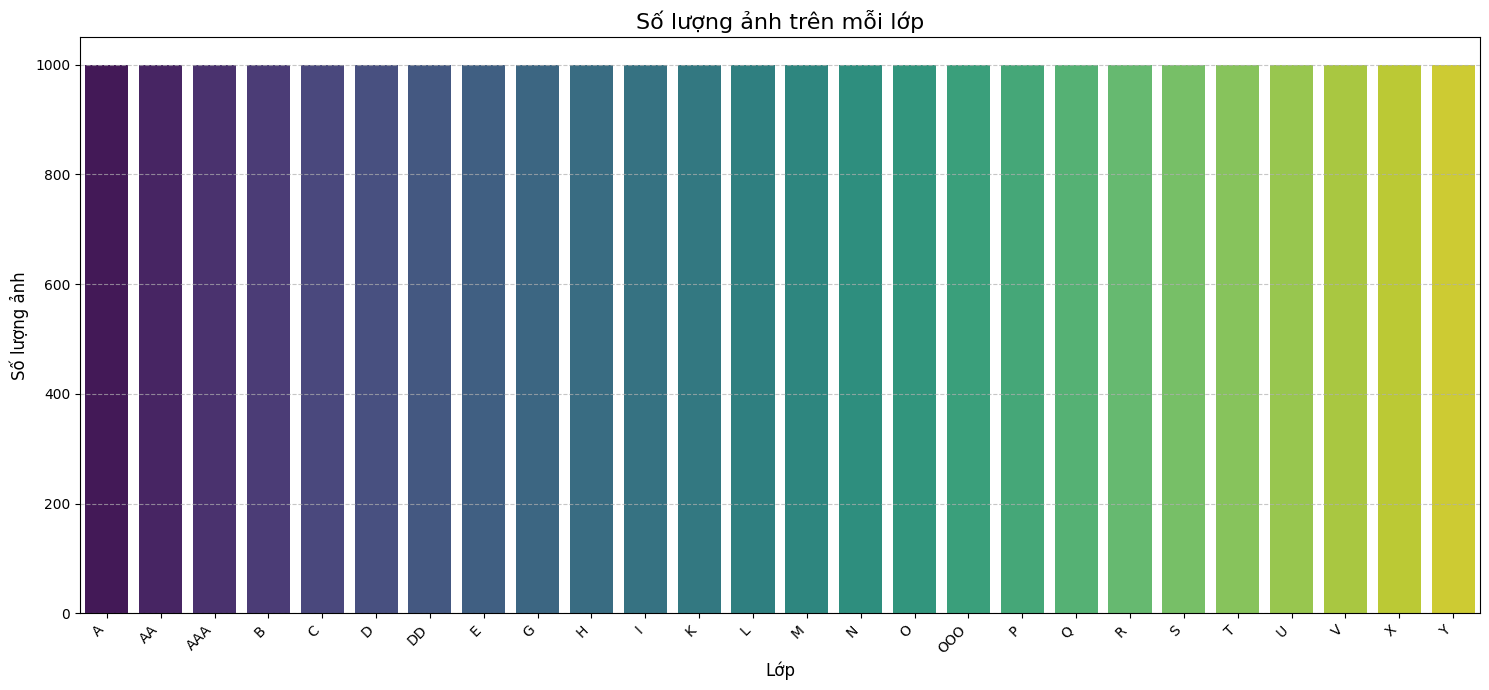

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sắp xếp các lớp theo tên để biểu đồ dễ đọc hơn
sorted_class_counts = dict(sorted(class_counts.items()))

# Tạo biểu đồ cột
plt.figure(figsize=(15, 7))
sns.barplot(x=list(sorted_class_counts.keys()), y=list(sorted_class_counts.values()), palette='viridis')

plt.title('Số lượng ảnh trên mỗi lớp', fontsize=16)
plt.xlabel('Lớp', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X để dễ đọc nếu có nhiều lớp
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Đảm bảo tất cả các thành phần của biểu đồ vừa vặn
plt.show()

## **II.2. Phân tích kích thước và tỉ lệ (Spatial Analysis)**

- Mô hình Deep Learning thường yêu cầu đầu vào có kích thước cố định (ví dụ: $224 \times 224$).

- Biểu đồ phân bố kích thước: Vẽ biểu đồ (Scatter plot hoặc Histogram) về chiều rộng (Width) và chiều cao (Height) của toàn bộ ảnh.
- Mục tiêu: Nếu ảnh quá nhỏ, khi phóng to để huấn luyện sẽ bị vỡ nét (pixelated). Nếu ảnh quá to, việc resize sẽ làm mất chi tiết nhỏ.
- Tỉ lệ khung hình (Aspect Ratio): Kiểm tra xem ảnh là hình vuông, chữ nhật đứng hay ngang. Nếu bạn ép tất cả về hình vuông, ảnh có bị méo (distort) quá mức không?

Đang thu thập thông tin kích thước ảnh...
Đã thu thập thông tin từ 26000 ảnh.

--- Phân tích thống kê kích thước ảnh ---
              Width        Height  Aspect Ratio
count  26000.000000  26000.000000  26000.000000
mean     326.382115    343.687385      0.994059
std      328.277651    407.909384      0.061924
min      224.000000    224.000000      0.530731
25%      224.000000    224.000000      1.000000
50%      224.000000    224.000000      1.000000
75%      224.000000    224.000000      1.000000
max     2018.000000   2914.000000      1.462422


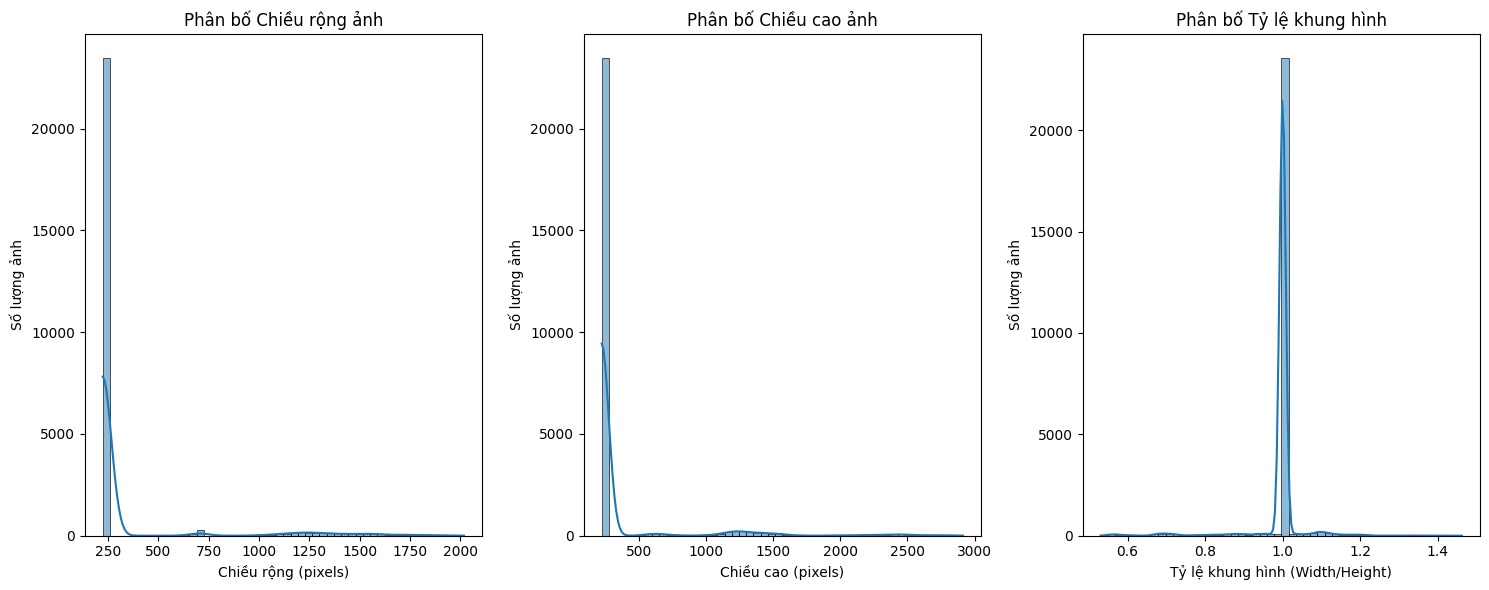

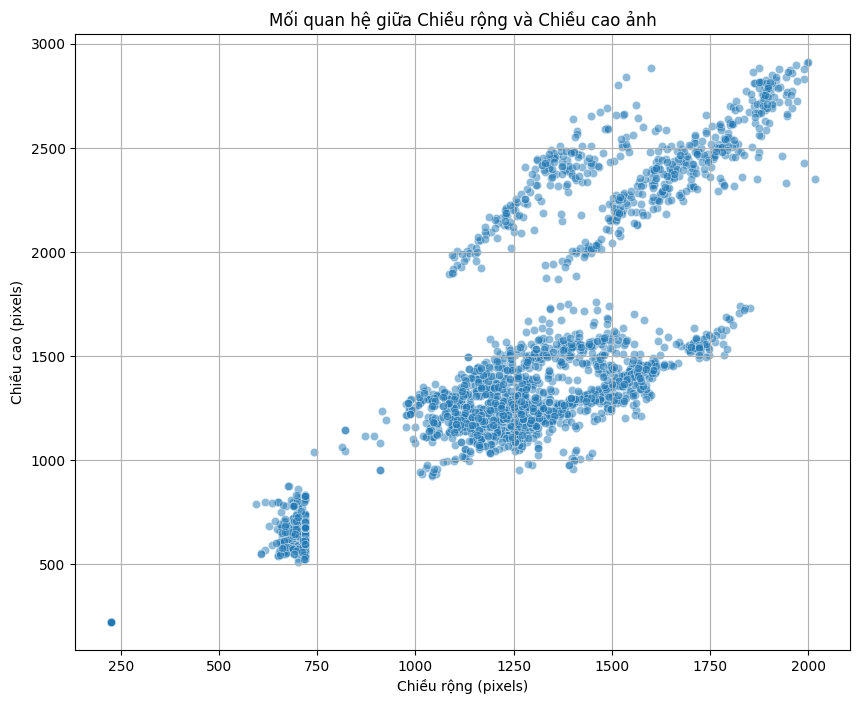


Hoàn tất phân tích kích thước và tỉ lệ ảnh.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Khởi tạo danh sách để lưu trữ kích thước ảnh
image_widths = []
image_heights = []
image_aspect_ratios = []

print("Đang thu thập thông tin kích thước ảnh...")

# Lặp qua tất cả các lớp và các tệp ảnh
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            if os.path.isfile(file_path) and filename.lower().endswith(valid_extensions):
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        image_widths.append(width)
                        image_heights.append(height)
                        image_aspect_ratios.append(width / height)
                except Exception as e:
                    # Bỏ qua các tệp không thể mở được (có thể đã được lọc ở bước trước, nhưng phòng hờ)
                    pass

print(f"Đã thu thập thông tin từ {len(image_widths)} ảnh.")

# Chuyển đổi sang DataFrame để dễ dàng phân tích và vẽ biểu đồ
df_sizes = pd.DataFrame({
    'Width': image_widths,
    'Height': image_heights,
    'Aspect Ratio': image_aspect_ratios
})

print("\n--- Phân tích thống kê kích thước ảnh ---")
print(df_sizes.describe())

# --- Vẽ biểu đồ phân bố kích thước ---
plt.figure(figsize=(15, 6))

# Biểu đồ Histogram cho chiều rộng
plt.subplot(1, 3, 1)
sns.histplot(df_sizes['Width'], bins=50, kde=True)
plt.title('Phân bố Chiều rộng ảnh')
plt.xlabel('Chiều rộng (pixels)')
plt.ylabel('Số lượng ảnh')

# Biểu đồ Histogram cho chiều cao
plt.subplot(1, 3, 2)
sns.histplot(df_sizes['Height'], bins=50, kde=True)
plt.title('Phân bố Chiều cao ảnh')
plt.xlabel('Chiều cao (pixels)')
plt.ylabel('Số lượng ảnh')

# Biểu đồ Histogram cho tỷ lệ khung hình
plt.subplot(1, 3, 3)
sns.histplot(df_sizes['Aspect Ratio'], bins=50, kde=True)
plt.title('Phân bố Tỷ lệ khung hình')
plt.xlabel('Tỷ lệ khung hình (Width/Height)')
plt.ylabel('Số lượng ảnh')

plt.tight_layout()
plt.show()

# Biểu đồ Scatter plot Chiều rộng vs Chiều cao
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Width', y='Height', data=df_sizes, alpha=0.5)
plt.title('Mối quan hệ giữa Chiều rộng và Chiều cao ảnh')
plt.xlabel('Chiều rộng (pixels)')
plt.ylabel('Chiều cao (pixels)')
plt.grid(True)
plt.show()

print("\nHoàn tất phân tích kích thước và tỉ lệ ảnh.")

**Nhận xét:**

**1. Phân tích thống kê (từ df_sizes.describe()):**
- **Width (Chiều rộng) và Height (Chiều cao):**

  - count: Có tổng cộng 26,000 ảnh đã được phân tích, cho thấy tất cả các ảnh đều hợp lệ và có thể mở được.
  - mean: Chiều rộng trung bình là khoảng 326 pixels, và chiều cao trung bình là khoảng 343 pixels.
  - std: Độ lệch chuẩn khá cao (khoảng 328 cho chiều rộng và 407 cho chiều cao), cho thấy sự biến động lớn về kích thước ảnh.
  - min: Chiều rộng và chiều cao tối thiểu đều là 224 pixels.
  - 25%, 50% (median), 75%: Đáng chú ý là 75% (đến tận quartile thứ ba) của các ảnh đều có kích thước 224x224 pixels. Điều này cho thấy một phần lớn dataset đã được chuẩn hóa về kích thước này.
  - max: Có những ảnh rất lớn, với chiều rộng tối đa lên đến 2018 pixels và chiều cao tối đa lên đến 2914 pixels.
- **Aspect Ratio (Tỷ lệ khung hình - Width/Height):**

  - mean: Tỷ lệ khung hình trung bình là khoảng 0.994, rất gần với 1.0, cho thấy phần lớn các ảnh là hình vuông hoặc gần hình vuông.
  - std: Độ lệch chuẩn là 0.0619, khá thấp, củng cố rằng tỷ lệ khung hình không quá đa dạng.
  - min: Tỷ lệ khung hình thấp nhất là 0.53, tức là có những ảnh có chiều cao gần gấp đôi chiều rộng (hình chữ nhật đứng).
  - max: Tỷ lệ khung hình cao nhất là 1.46, tức là có những ảnh có chiều rộng lớn hơn chiều cao khoảng 1.5 lần (hình chữ nhật ngang).

**2. Giải thích biểu đồ:**
- **Phân bố Chiều rộng ảnh & Phân bố Chiều cao ảnh (Histograms):**

  - Cả hai biểu đồ histogram cho chiều rộng và chiều cao đều hiển thị một đỉnh rất cao và rõ ràng tại 224 pixels. Điều này xác nhận rằng đại đa số các ảnh trong dataset đã được resize thành 224x224 pixels.
  - Ngoài ra, có một số lượng nhỏ các ảnh có kích thước lớn hơn, tạo thành các phân bố kéo dài về phía bên phải, nhưng chúng ít nổi bật hơn nhiều so với đỉnh 224.
- **Phân bố Tỷ lệ khung hình (Histogram):**

  - Biểu đồ này cho thấy một đỉnh rất cao tại tỷ lệ khung hình 1.0, chứng tỏ hầu hết các ảnh là hình vuông.
  - Có một số lượng nhỏ ảnh có tỷ lệ khung hình khác 1.0 (nhỏ hơn hoặc lớn hơn 1.0), nhưng chúng không chiếm phần lớn.
- **Mối quan hệ giữa Chiều rộng và Chiều cao ảnh (Scatter Plot):**

  - Biểu đồ scatter plot thể hiện một cụm điểm rất dày đặc tại tọa độ (224, 224). Đây là minh chứng rõ ràng nhất cho việc phần lớn dataset bao gồm các ảnh có kích thước 224x224.

**TÓM TẮT:** Dataset này chủ yếu bao gồm các ảnh đã được chuẩn hóa về kích thước $224 \times 224$ pixels và có tỷ lệ khung hình vuông (1:1). Tuy nhiên, vẫn có một số lượng nhỏ ảnh với kích thước và tỷ lệ khung hình đa dạng hơn. Điều này là một thông tin quan trọng khi bạn chuẩn bị dữ liệu cho mô hình Deep Learning, vì các mô hình thường yêu cầu kích thước đầu vào đồng nhất. Bạn có thể cần áp dụng các phương pháp tiền xử lý như resizing hoặc cropping cho các ảnh không phải $224 \times 224$ để chúng phù hợp với yêu cầu của mô hình.

## **II.3. Kiểm tra trực quan (Visual Inspection)**

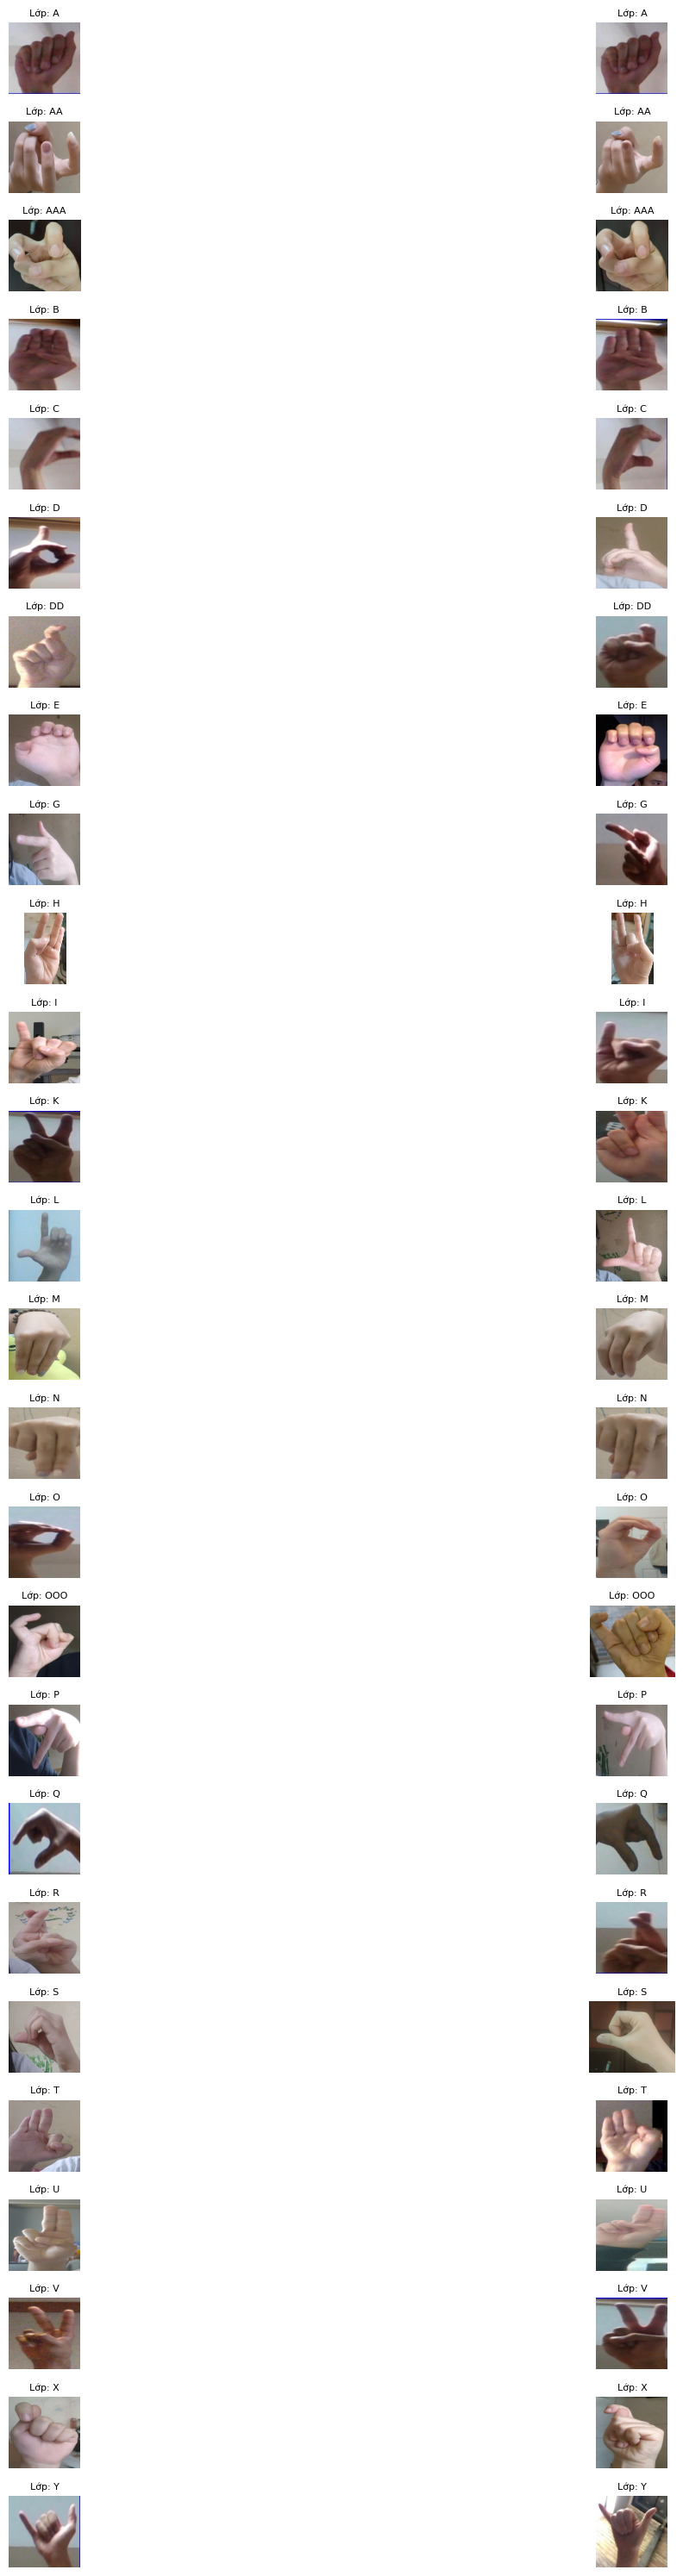

Hoàn tất kiểm tra trực quan ảnh mẫu.


In [ ]:
import random
num_samples_per_class = 2  # Số lượng ảnh mẫu muốn hiển thị cho mỗi lớp

plt.figure(figsize=(20, 30)) # Tăng kích thước tổng thể của biểu đồ để xem rõ hơn
plot_index = 1

# Lặp qua từng lớp đã được phát hiện
for class_name in sorted(class_counts.keys()): # Sắp xếp để hiển thị theo thứ tự
    class_path = os.path.join(data_dir, class_name)

    # Lấy danh sách tất cả các tệp ảnh trong lớp này
    all_images_in_class = [os.path.join(class_path, f) for f in os.listdir(class_path)
                           if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(valid_extensions)]

    # Chọn ngẫu nhiên một số ảnh mẫu từ lớp này
    if len(all_images_in_class) > 0:
        sample_images = random.sample(all_images_in_class, min(len(all_images_in_class), num_samples_per_class))

        for img_path in sample_images:
            try:
                img = Image.open(img_path)

                # Điều chỉnh số lượng hàng và cột cho phù hợp với kích thước mới và số lượng lớp
                plt.subplot(len(class_counts), num_samples_per_class, plot_index)
                plt.imshow(img)
                plt.title(f"Lớp: {class_name}", fontsize=8)
                plt.axis('off') # Tắt trục tọa độ
                plot_index += 1
            except Exception as e:
                print(f"Không thể mở tệp hình ảnh {img_path}: {e}")

plt.tight_layout()
plt.show()

print("Hoàn tất kiểm tra trực quan ảnh mẫu.")

## **II.4. Phân tích phân bố cường độ pixel (Color & Intensity)**

Đây là bước cực kỳ quan trọng để chuẩn bị cho phần Tiền xử lý (Preprocessing).

- Color Histograms: Vẽ biểu đồ phân bố độ sáng cho 3 kênh màu Red, Green, Blue.

- Mục tiêu: Phát hiện ảnh bị quá tối, quá sáng hoặc bị ám màu (color cast).

- Tính Mean và Std: Tính giá trị trung bình và độ lệch chuẩn của pixel trên toàn bộ tập dữ liệu.

  - Mục tiêu: Dùng các thông số này để thực hiện Normalization (Chuẩn hóa), giúp mô hình hội tụ nhanh hơn.

Đang thu thập dữ liệu cường độ pixel...
Đã xử lý 2000 ảnh...
Đã xử lý 4000 ảnh...
Đã xử lý 6000 ảnh...
Đã xử lý 8000 ảnh...
Đã xử lý 10000 ảnh...
Đã xử lý 12000 ảnh...
Đã xử lý 14000 ảnh...
Đã xử lý 16000 ảnh...
Đã xử lý 18000 ảnh...
Đã xử lý 20000 ảnh...
Đã xử lý 22000 ảnh...
Đã xử lý 24000 ảnh...
Đã xử lý 26000 ảnh...
Hoàn tất thu thập dữ liệu cường độ pixel từ 26000 ảnh.


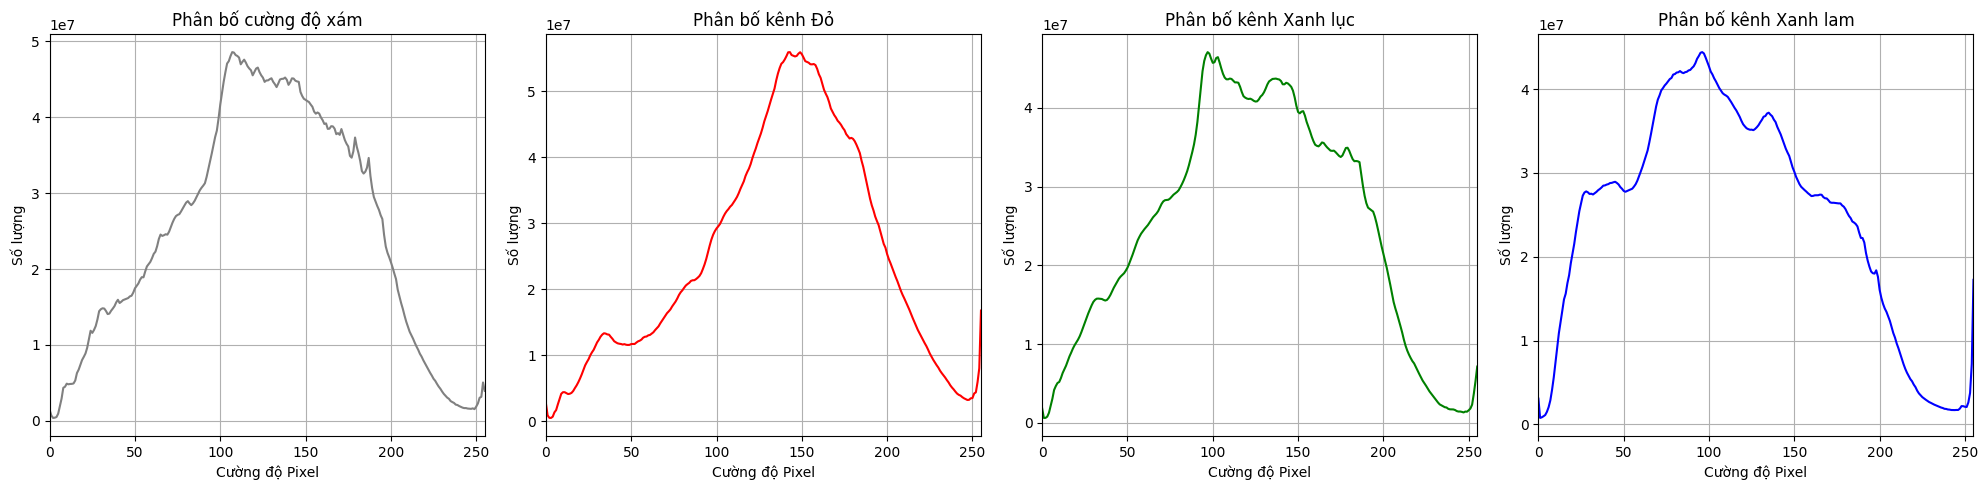

Hoàn tất phân tích phân bố cường độ pixel và màu sắc.


In [ ]:
import numpy as np

# 256 bins for each channel
hist_gray = np.zeros(256, dtype=int)
hist_red = np.zeros(256, dtype=int)
hist_green = np.zeros(256, dtype=int)
hist_blue = np.zeros(256, dtype=int)

processed_images_count = 0

print("Đang thu thập dữ liệu cường độ pixel...")

# Iterate through all images to accumulate pixel intensity and color data
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            if os.path.isfile(file_path) and filename.lower().endswith(valid_extensions):
                try:
                    with Image.open(file_path) as img:
                        # Convert to RGB to ensure 3 channels for R, G, B consistency
                        img_rgb = img.convert("RGB")
                        # Convert to grayscale for overall intensity
                        img_gray = img.convert("L") # 'L' mode for grayscale

                        # Accumulate histogram for grayscale
                        hist_gray += np.array(img_gray.histogram())

                        # Accumulate histograms for R, G, B channels
                        # Image.histogram() returns concatenated histograms: [R_bins, G_bins, B_bins]
                        r_hist = img_rgb.histogram()[0:256]
                        g_hist = img_rgb.histogram()[256:512]
                        b_hist = img_rgb.histogram()[512:768]

                        hist_red += np.array(r_hist)
                        hist_green += np.array(g_hist)
                        hist_blue += np.array(b_hist)

                        processed_images_count += 1
                        if processed_images_count % 2000 == 0:
                            print(f"Đã xử lý {processed_images_count} ảnh...")

                except Exception as e:
                    # In case of any issues with a specific file, log and continue
                    print(f"Cảnh báo: Không thể xử lý tệp hình ảnh {file_path}: {e}")

print(f"Hoàn tất thu thập dữ liệu cường độ pixel từ {processed_images_count} ảnh.")

# Plotting the histograms
plt.figure(figsize=(20, 5))

# Grayscale Intensity Histogram
plt.subplot(1, 4, 1)
plt.title('Phân bố cường độ xám', fontsize=12)
plt.xlabel('Cường độ Pixel', fontsize=10)
plt.ylabel('Số lượng', fontsize=10)
plt.plot(hist_gray, color='gray')
plt.xlim([0, 255])
plt.grid(True)

# Red Channel Histogram
plt.subplot(1, 4, 2)
plt.title('Phân bố kênh Đỏ', fontsize=12)
plt.xlabel('Cường độ Pixel', fontsize=10)
plt.ylabel('Số lượng', fontsize=10)
plt.plot(hist_red, color='red')
plt.xlim([0, 255])
plt.grid(True)

# Green Channel Histogram
plt.subplot(1, 4, 3)
plt.title('Phân bố kênh Xanh lục', fontsize=12)
plt.xlabel('Cường độ Pixel', fontsize=10)
plt.ylabel('Số lượng', fontsize=10)
plt.plot(hist_green, color='green')
plt.xlim([0, 255])
plt.grid(True)

# Blue Channel Histogram
plt.subplot(1, 4, 4)
plt.title('Phân bố kênh Xanh lam', fontsize=12)
plt.xlabel('Cường độ Pixel', fontsize=10)
plt.ylabel('Số lượng', fontsize=10)
plt.plot(hist_blue, color='blue')
plt.xlim([0, 255])
plt.grid(True)

plt.tight_layout()
plt.show()

print("Hoàn tất phân tích phân bố cường độ pixel và màu sắc.")

### **Giải thích kết quả phân tích Pixel Intensity & Color**

#### **1. Phân bố cường độ xám (Grayscale Intensity):**
- Biểu đồ này cho biết độ sáng tổng thể của dataset.
- **Nếu lệch trái (vùng 0-50):** Dataset có nhiều ảnh tối hoặc phông nền đen.
- **Nếu lệch phải (vùng 200-255):** Dataset có nhiều ảnh sáng hoặc phông nền trắng.
- **Nếu có các đỉnh (peaks) rõ rệt:** Cho thấy có những mức độ sáng xuất hiện lặp đi lặp lại (thường là do phông nền đồng nhất).

#### **2. Phân bố các kênh màu (Red, Green, Blue):**
- **Sự đồng nhất:** Nếu cả 3 biểu đồ R, G, B có hình dạng tương tự nhau, dataset có xu hướng trung tính về màu sắc (gần với ảnh xám).
- **Sự khác biệt:**
    - Nếu kênh **Đỏ (Red)** cao hơn ở vùng cường độ cao, ảnh có nhiều tông màu ấm.
    - Nếu kênh **Xanh lam (Blue)** cao hơn, ảnh có thể có nhiều ánh sáng lạnh hoặc được chụp dưới điều kiện ánh sáng xanh.
- **Phát hiện phông nền:** Trong các bộ dữ liệu nhận dạng cử chỉ tay (Sign Language), các đỉnh cao ở cường độ pixel thấp thường đại diện cho phông nền tối, trong khi các dải cường độ trung bình và cao đại diện cho tông màu da của bàn tay.

**Kết luận:** Việc hiểu rõ phân bố này giúp chúng ta quyết định các bước Pre-processing như **Normalization** (chuẩn hóa) hoặc **Histogram Equalization** để mô hình học tập tốt hơn, không bị ảnh hưởng bởi điều kiện ánh sáng khác nhau.

## **II.5. Phân tích phân bố cường độ pixel (Color & Intensity)**

- Độ mờ (Blur detection): Sử dụng toán tử Laplacian để tính độ sắc nét. Ảnh quá mờ có thể cần bị loại bỏ.

- Tìm ảnh trùng lặp (Duplicates): Sử dụng Image Hashing để tìm các ảnh giống hệt nhau hoặc gần giống nhau.

- Mục tiêu: Tránh việc ảnh trong tập Train xuất hiện lại ở tập Test (gây ra kết quả ảo).

Đang phân tích độ mờ và tìm ảnh trùng lặp (lấy mẫu 100 ảnh mỗi lớp để tiết kiệm thời gian)...


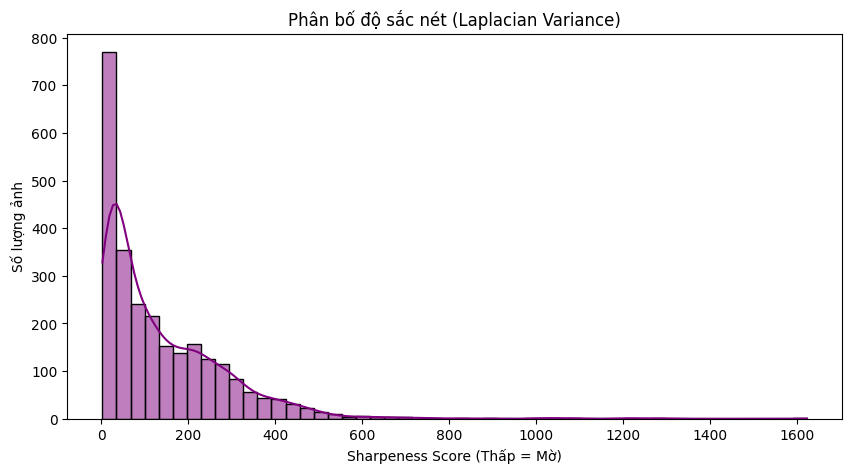

--- Kết quả ---
Điểm sắc nét trung bình: 138.15
Số lượng nhóm ảnh có dấu hiệu trùng lặp: 1
Ví dụ một số tệp trùng lặp:
- ['/content/data/Dataset/G/1_247.jpg', '/content/data/Dataset/G/247.jpg']


In [ ]:
import cv2
import hashlib
from collections import defaultdict
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

def estimate_blur(image_path):
    image = cv2.imread(image_path)
    if image is None: return 0
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Tính toán biến thiên của Laplacian
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = []
hash_dict = defaultdict(list)
duplicates = []

print("Đang phân tích độ mờ và tìm ảnh trùng lặp (lấy mẫu 100 ảnh mỗi lớp để tiết kiệm thời gian)...")

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        filenames = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
        # Lấy mẫu để phân tích nhanh
        sample_files = random.sample(filenames, min(len(filenames), 100))

        for filename in sample_files:
            file_path = os.path.join(class_path, filename)

            # 1. Blur detection
            try:
                score = estimate_blur(file_path)
                blur_scores.append(score)
            except:
                pass

            # 2. Duplicate detection (Simple MD5 hash on resized image for speed)
            try:
                with Image.open(file_path) as img:
                    img_small = img.resize((32, 32), Image.Resampling.LANCZOS).convert('L')
                    img_hash = hashlib.md5(img_small.tobytes()).hexdigest()
                    hash_dict[img_hash].append(file_path)
            except:
                pass

# Tìm các hash có nhiều hơn 1 tệp
for h, paths in hash_dict.items():
    if len(paths) > 1:
        duplicates.append(paths)

# Vẽ biểu đồ độ mờ
plt.figure(figsize=(10, 5))
sns.histplot(blur_scores, bins=50, kde=True, color='purple')
plt.title('Phân bố độ sắc nét (Laplacian Variance)')
plt.xlabel('Sharpeness Score (Thấp = Mờ)')
plt.ylabel('Số lượng ảnh')
plt.show()

print(f"--- Kết quả ---")
# Đã sửa lỗi xuống dòng trong f-string ở đây
print(f"Điểm sắc nét trung bình: {np.mean(blur_scores):.2f}")
print(f"Số lượng nhóm ảnh có dấu hiệu trùng lặp: {len(duplicates)}")
if duplicates:
    print("Ví dụ một số tệp trùng lặp:")
    for d in duplicates[:3]:
        print(f"- {d}")